# A first look at the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
prices = pd.read_csv("../data/raw/prices_IT_2012_2024.csv", index_col=0, parse_dates=True)

In [4]:
prices.describe()

,0
count,78784.000000
mean,92.610596
std,94.973594
min,0.000000
25%,42.840000
50%,55.350000
75%,100.735000
max,870.000000


In [5]:
prices.isna().sum()

0    0
dtype: int64

In [6]:
prices.index = pd.to_datetime(prices.index, utc=True)
print(type(prices.index))

<class 'pandas.DatetimeIndex'>


In [7]:
print(f"Period: {prices.index.min()} -> {prices.index.max()}")

Period: 2015-01-04 23:00:00+00:00 -> 2023-12-31 23:00:00+00:00


In [8]:
print(prices[prices['0']<=0].count())
print(prices[prices['0']<=10].count())

0    54
dtype: int64
0    716
dtype: int64


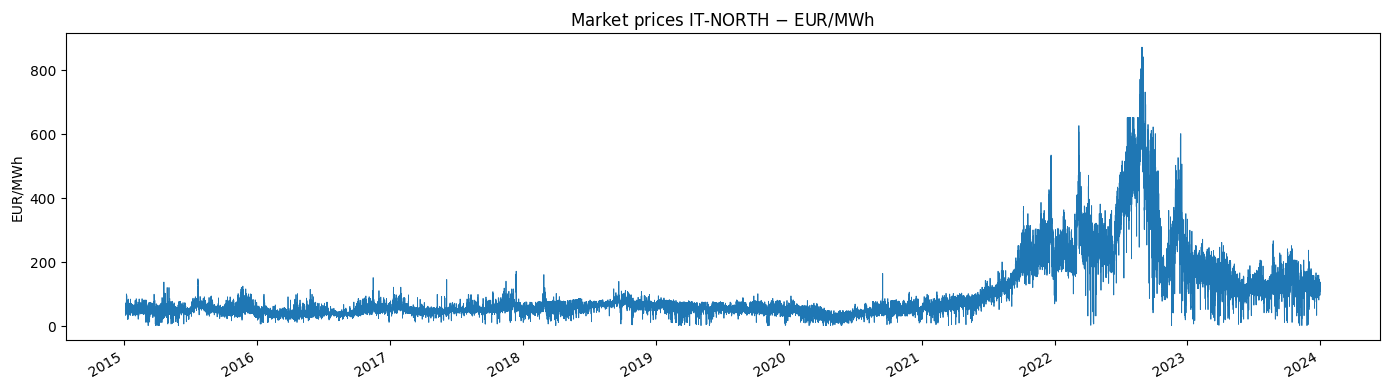

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
prices.plot(ax=ax, linewidth=0.6, color="C0", legend=False)
ax.set_title("Market prices IT-NORTH $-$ EUR/MWh")
ax.set_ylabel("EUR/MWh")
# ax.tick_params(axis='x', labelrotation=10)
plt.tight_layout()
plt.savefig("../data/processed/01_market_prices.png", dpi=150)

In this notebook I carried out a simple description of the dataset. There are no "holes" in the time series, but in 54 istances the price is zero and 716 times it is below 10 EUR/MWh, which is credible. This dataset includes data from the Covid lockdown and from the global gas crysis. Such outliers will be significative to avoid overfitting on standard behaviour.